In [87]:
import pandas as pd 
import plotly.graph_objects as go

## Group 1

In [88]:
df=pd.read_csv('medals.csv') 
df.head(1)

,medal_type,medal_code,medal_date,name,gender,discipline,event,event_type,url_event,code,country_code,country,country_long
0,Gold Medal,1.0,2024-07-27,Remco EVENEPOEL,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903136,BEL,Belgium,Belgium


In [89]:
country_counts=df['country_long'].value_counts() 
country_counts.head(1)

country_long
United States of America    126
Name: count, dtype: int64

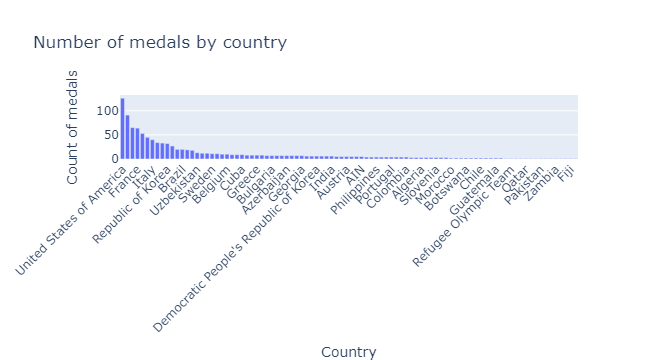

In [90]:
bar_fig=go.Figure(data=[ 
    go.Bar(x=country_counts.index,  
           y=country_counts.values) 
    ]
                 ) 

bar_fig.update_layout( 
    title="Number of medals by country", 
    xaxis_title="Country", 
    yaxis_title="Count of medals", 
    xaxis_tickangle=-45
) 

bar_fig.show()
                  

In [91]:
medal_count = df.groupby(['country_long', 'medal_type']).size().unstack()
medal_count.head(2)

medal_type,Bronze Medal,Gold Medal,Silver Medal
country_long,,,
AIN,1.0,1.0,3.0
Albania,2.0,NaN,NaN


(fill_value=0)  = to replace NaN values with 0

In [92]:
medal_count = df.groupby(['country_long', 'medal_type']).size().unstack(fill_value=0) 
medal_count.head(2)

medal_type,Bronze Medal,Gold Medal,Silver Medal
country_long,,,
AIN,1,1,3
Albania,2,0,0


In [93]:
medal_order=['Gold Medal', 'Silver Medal', 'Bronze Medal'] 
medal_count = medal_count[medal_order] 
medal_count.head(1)

medal_type,Gold Medal,Silver Medal,Bronze Medal
country_long,,,
AIN,1,3,1


In [94]:
medal_count['Total']=medal_count.sum(axis=1) 
#if axis = 0 it will sum up the columns 
#if axis = 1 it will sum up the rows (it will sum across columns for each particular row)

medal_count_sorted=medal_count.sort_values(by='Total', ascending=False) 
medal_count_sorted_top10=medal_count_sorted.head(10) 
medal_count_sorted_top10.head(1)

medal_type,Gold Medal,Silver Medal,Bronze Medal,Total
country_long,,,,
United States of America,40,44,42,126


In [95]:
country_names=medal_count_sorted_top10.index 
total_medals=medal_count_sorted_top10['Total']

In [96]:
medals_info=[ 
    ('Bronze Medal', '#cd7f32', 'Bronze Medals'), 
    ('Silver Medal', 'silver', 'Silver Medals'), 
    ('Gold Medal', 'gold', 'Gold Medals'), 
] 

traces=[] 

for medal_name, color, hover_label in medals_info: 
    if medal_name == 'Gold Medal': 
        hovertemplate= f"<b>Total Medals:</b>" + total_medals.astype(str) + f"<br><b>{hover_label}:</b> %{{y}}<extra></extra>"   
        opacity=1 
        line=dict(
            color='black', 
            width=1.5
        ) 

    else: 
        hovertemplate= f'<b>{hover_label}:</b> %{{y}}<extra></extra>' 
        opacity=1  
        line=dict() 
        
    traces.append(go.Bar( 
        x=medal_count_sorted_top10.index, 
        y=medal_count_sorted_top10[medal_name], 
        name=medal_name.split()[0], 
        hovertemplate=hovertemplate, 
        marker= dict(
            color=color, 
            opacity=opacity,
            line=line
)
    ) 
)

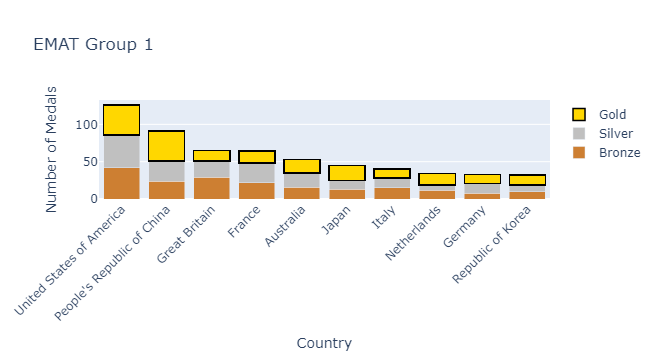

In [97]:
stacked_bar_fig=go.Figure(data=traces) 

stacked_bar_fig.update_layout( 
    barmode='stack', 
    title='EMAT Group 1', 
    xaxis_title='Country', 
    yaxis_title="Number of Medals",  
    xaxis_tickangle =-45, 
    hovermode='x unified', 
    hoverlabel=dict( 
        bgcolor ='white', 
        font_size=12, 
        font_family='Arial'
    )

)


In [98]:
stacked_bar_fig.write_html('Stacked Chart.html')

In [99]:
stacked_bar_fig.write_html('Stacked Chart.html')

In [100]:
# stacked_bar_fig.write_image('Stacked Chart.pdf', format='pdf')  

## Group 2

In [101]:
df = pd.read_csv('USA_cars_datasets.csv') 
df.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [102]:
df.drop(['Unnamed: 0'], axis=1, inplace= True)
df.head()

,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [103]:
df.isnull().sum()

price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
vin             0
lot             0
state           0
country         0
condition       0
dtype: int64

In [104]:
df_brand = df['brand'].value_counts().sort_values(ascending= False).reset_index() 
df_state = df['state'].value_counts().sort_values(ascending= False).reset_index()

In [105]:
df_brand

,brand,count
0,ford,1235
1,dodge,432
2,nissan,312
3,chevrolet,297
4,gmc,42
5,jeep,30
6,chrysler,18
7,bmw,17
8,hyundai,15
9,kia,13


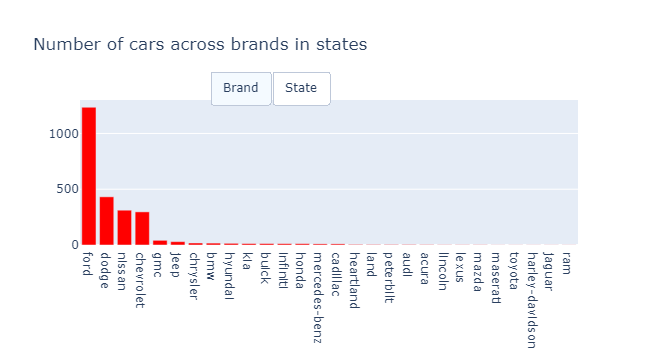

In [106]:
fig = go.Figure() 

fig.add_trace( 
    go.Bar(x=df_brand['brand'], y=df_brand['count'], name= 'Brand count', 
           marker_color = 'red')  
) 

fig.add_trace( 
    go.Bar(x=df_state['state'], y=df_state['count'], name= 'State count', 
           marker_color = 'blue')  
) 

fig.data[1].visible = False 

fig.update_layout( 
    updatemenus= [
        dict( 
            type='buttons', 
            direction='right', 
            active=0, 
            x=0.5, 
            y=1.2, 
            buttons=list([
                dict(label="Brand", 
                     method='update', 
                     args=[{'visible':[True, False]}, 
                         {'title': 'Number of cars for brands'}]),
                dict(label='State', 
                     method='update', 
                     args=[{'visible': [False, True]}, 
                           {'title': 'Number of cars in different states'}])
            ])
        ) 
    ]
) 

fig.update_layout(title_text="Number of cars across brands in states") 

fig.show()

In [107]:
fig2 = go.Figure() 

brands = sorted(df['brand'].unique())  
brands

['acura',
 'audi',
 'bmw',
 'buick',
 'cadillac',
 'chevrolet',
 'chrysler',
 'dodge',
 'ford',
 'gmc',
 'harley-davidson',
 'heartland',
 'honda',
 'hyundai',
 'infiniti',
 'jaguar',
 'jeep',
 'kia',
 'land',
 'lexus',
 'lincoln',
 'maserati',
 'mazda',
 'mercedes-benz',
 'nissan',
 'peterbilt',
 'ram',
 'toyota']

In [108]:
for brand in brands: 
    dff = df[df['brand'] == brand] 
    fig2.add_trace(go.Scatter( 
    x=dff['mileage'], 
    y=dff['price'], 
    mode='markers', 
    name=brand 
    )) 


buttons =[] 

for brand in ["All"] + brands: 

    visible = [brand == trace.name or 'All' == brand for trace in fig2.data] 
    button = dict(label=brand,  
                    method = 'update', 
                    args=[{'visible': visible}, 
                            {'title': f'Price vs Mileage: {brand}'}]) 

    buttons.append(button) 



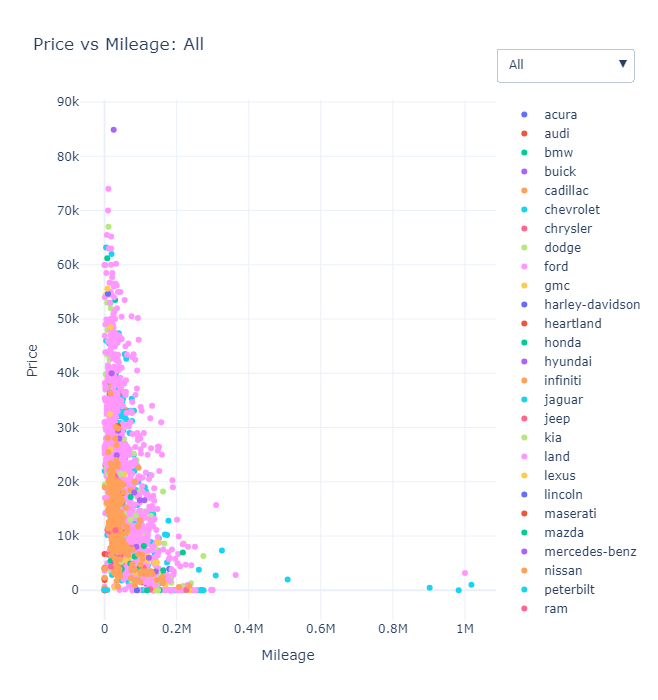

In [109]:
fig2.update_layout( 
    updatemenus=[ 
        dict(active=0, 
             buttons=buttons, 
             x=1, 
             xanchor='left', 
             y=1.1, 
             yanchor='top') 
    ], 
    title='Price vs Mileage: All', 
    xaxis_title='Mileage', 
    yaxis_title='Price', 
    height= 700, 
    template = 'plotly_white' 
)

fig2.show()

## Group 3

In [110]:
import plotly.express as px

In [111]:
df=pd.read_csv('AB_NYC_2019.csv') 

In [112]:
df.shape

(48895, 16)

In [113]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [114]:
mv = df.isnull().sum() 
mv

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

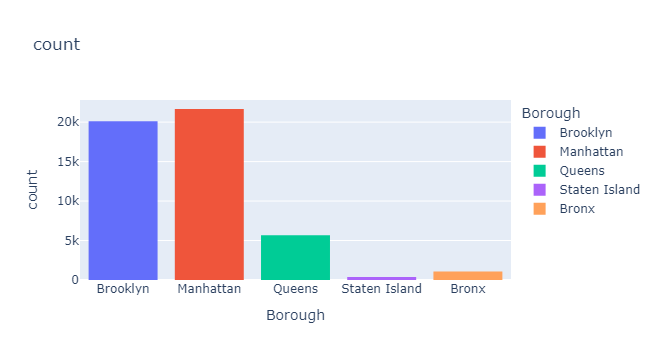

In [115]:
fig1 = px.histogram(df, x='neighbourhood_group', title='count', 
                    labels={'neighbourhood_group':'Borough', 'count': 'Number of Listings'}, color='neighbourhood_group') 
fig1.show()

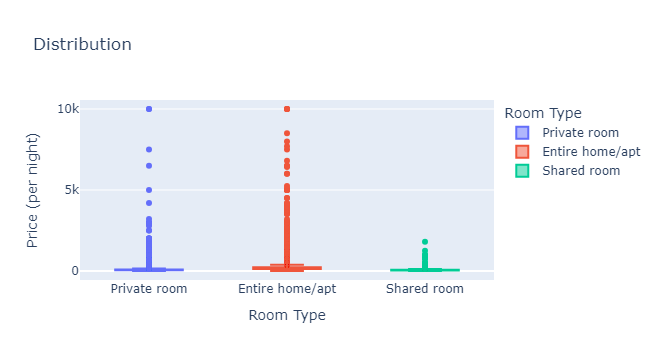

In [116]:
fig2 = px.box(df, x='room_type', y='price', title='Distribution', 
              labels={'room_type':'Room Type', 'price':'Price (per night)'}, color='room_type') 
fig2.show()

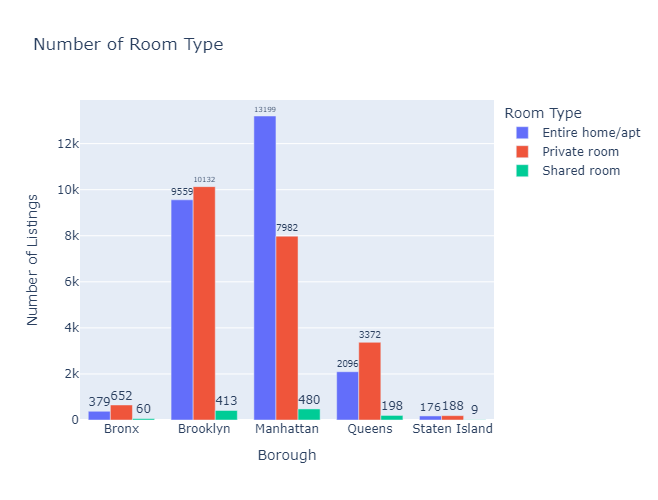

In [117]:
room_count = df.groupby(['neighbourhood_group', 'room_type']).size().reset_index(name='count') 
fig =px.bar(room_count, x='neighbourhood_group', y='count', color='room_type', 
            title='Number of Room Type',
            labels={'neighbourhood_group':'Borough','count': 'Number of Listings', 'room_type': 'Room Type'}, 
            barmode='group', 
            text='count')   

fig.update_traces(textposition='outside', textfont_size=12) 
fig.update_layout(height=500) 

fig.show()



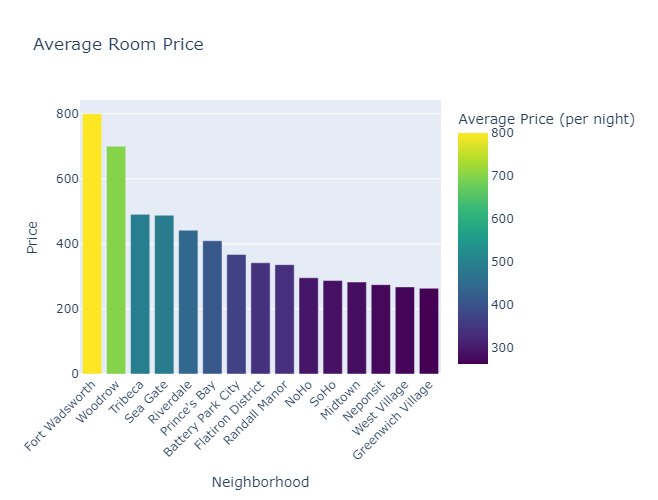

In [118]:
average_price_neighborhood = df.groupby('neighbourhood')['price'].mean().reset_index() 

top_15_neighborhoods = average_price_neighborhood.sort_values(by='price', ascending=False).head(15) 

fig= px.bar(top_15_neighborhoods, x='neighbourhood', y='price', 
            title='Average Room Price', 
            labels={'neighbourhood': 'Neighbourhood', 'price': 'Average Price (per night)'}, 
            color='price', 
            color_continuous_scale=px.colors.sequential.Viridis)  
fig.update_layout(xaxis_title='Neighborhood', yaxis_title='Price', 
                  xaxis_tickangle=-45, 
                  width=700, 
                  height=500) 

fig.show()